Notebook to repeat the analysis of sort-seq data, but using the mean fluorescence of each bin.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.stats as stats
import math
import statsmodels.api as sm
from matplotlib import cm
import matplotlib.colors as colors
from matplotlib.patches import Rectangle
from matplotlib.patches import Polygon
import matplotlib.gridspec as gridspec

## Importing genotype frequency data

In [4]:
counts_all = pd.read_csv("SortSeq_data/counts_all_SortSeq_25-02.csv")
info_file = pd.read_csv("SortSeq_data/Libs_info_SortSeq_25-02-18_SA.csv")

counts_all = counts_all.drop(columns=['Mut_categories', 'n_mutated'])

## Computing expression levels and filtering genotypes

In [6]:
# Getting lists of sample names, biological replicates and technical replicates
sample_names = list(info_file['Sample_name'].apply(lambda x: x.split('_')[0]).unique())
bio_reps = [f'b{x}' for x in list(info_file['Bio_rep'].unique())]
tech_reps = ['t1', 't2']

Instead of using bin numbers, the mean fluorescence obtained from three pre-sorting samples is used (Gating_flow_cytometry.ipynb) 

In [8]:
# Preparing dictionaries giving 'expression value' and number of sorted cells for each kind of sample
exp_dict = {'dead_N': 371.88635899, 'weak_N': 1755.53615962, 'medweak_N': 2836.55570859,
           'medstrong_N': 4462.68914929, 'strong_N': 7326.32418516}
cell_dict= {'dead_N': 10000, 'weak_N': 10000, 'medweak_N': 50000,
           'medstrong_N': 50000, 'strong_N': 10000}

In [9]:
# Defining functions to compute a weighted average of bins for each genotype, serving as an expression score

def calc_mean_bin(df, col_exp_dict, total_cols, freq_norm=False):
    """Calculate weighted average of bins, without normalizing by the number of sorted cells."""
    mean_num = 0
    mean_denom = 0
    for col in df.columns:
        if freq_norm:
            mean_term = df[col] / total_cols[f"{col.split('_')[0]}_Total"]
            mean_num += col_exp_dict[col] * mean_term
            mean_denom += mean_term

        else:
            mean_term = df[col]
            mean_num += mean_term * col_exp_dict[col]
            mean_denom += mean_term

    mean_bin = mean_num / mean_denom

    return mean_bin


def calc_bin_cell_norm(df, col_exp_dict, col_cell_dict, total_cols, freq_norm=False):
    """Calculate weighted average of bins, while normalizing by the number of sorted cells."""
    mean_num = 0
    mean_denom = 0
    cell_tot = np.sum(list(col_cell_dict.values()))
    for col in df.columns:
        cell_num = col_cell_dict[col]
        if freq_norm:
            mean_term = (df[col] / total_cols[f"{col.split('_')[0]}_Total"]) * (cell_num / cell_tot)
            mean_num += col_exp_dict[col] * mean_term
            mean_denom += mean_term

        else:
            mean_term = df[col] * (cell_num / cell_tot)
            mean_num += col_exp_dict[col] * mean_term
            mean_denom += mean_term

    mean_bin = mean_num / mean_denom

    return mean_bin

### Computing expression scores

In [11]:
sort_model = pd.DataFrame(columns=['Bio_rep', 'Tech_rep', 'Lib_code', 'Genotype', 'Mutation type', 'Position',
                                   'T0_N', 'T0_Total', 'dead_N', 'dead_Total', 'weak_N',
                                   'weak_Total', 'medweak_N', 'medweak_Total', 'medstrong_N', 
                                   'medstrong_Total', 'strong_N', 'strong_Total', 'Reads_all_bins',
                                   'Mean_bin', 'Mean_cell_norm', 'WT_bin', 'WT_cell_norm',
                                   'Diff_bin', 'Diff_bin_cell_norm'])

sort_all = sort_model.copy()

for bio_id in bio_reps:

    for tech_id in tech_reps:
        current_df = pd.DataFrame(columns=['Bio_rep', 'Tech_rep', 'Genotype', 'Mutation type', 'Position'])

        for samp_type in sample_names:
            if samp_type == 'T0':
                lib_name = f'{samp_type}_{bio_id}'

            else:
                lib_name = f'{samp_type}_{bio_id}_{tech_id}'

            lib_subset = counts_all[counts_all['Library'] == lib_name].copy().reset_index(drop=True)
            lib_subset = lib_subset[['Genotype', 'Mutation type', 'Position', 'N_reads', 'Total_reads']].copy()
            lib_subset = lib_subset.rename(columns={'N_reads': f'{samp_type}_N', 'Total_reads': f'{samp_type}_Total'})
            lib_subset['Bio_rep'] = bio_id[-1]
            lib_subset['Tech_rep'] = tech_id[-1]
            current_df = pd.merge(current_df, lib_subset, on=['Bio_rep', 'Tech_rep','Genotype', 'Mutation type', 'Position'], how='outer')

        # Filling in the na values
        for col_type in sample_names:
            mean_tofill = np.mean(current_df[f'{col_type}_Total'].dropna())
            current_df[f'{col_type}_Total'] = current_df[f'{col_type}_Total'].fillna(mean_tofill)

        current_df = current_df.fillna(0)
        
        current_df['Reads_all_bins'] = current_df[['dead_N', 'weak_N', 'medweak_N', 'medstrong_N', 'strong_N']].sum(axis=1)
        current_df['Mean_cell_norm'] = calc_bin_cell_norm(current_df[['dead_N', 'weak_N', 'medweak_N', 'medstrong_N', 'strong_N']],
                                                    exp_dict, cell_dict, current_df[['dead_Total', 'weak_Total', 'medweak_Total',
                                                                                     'medstrong_Total', 'strong_Total']], freq_norm=True)
        current_df['Mean_bin'] = calc_mean_bin(current_df[['dead_N', 'weak_N', 'medweak_N', 'medstrong_N', 'strong_N']],
                                                     exp_dict, current_df[['dead_Total', 'weak_Total', 'medweak_Total',
                                                                           'medstrong_Total', 'strong_Total']], freq_norm=True)
        wt_slice = current_df[current_df['Genotype'] == 'WT'].copy()
        wt_bin = wt_slice['Mean_bin'].values[0]
        wt_bin_norm = wt_slice['Mean_cell_norm'].values[0]

        current_df['WT_bin'] = wt_bin
        current_df['WT_cell_norm'] = wt_bin_norm
        # Computing WT-relative fluorescence rather than the Delta_norm used in the paper
        current_df['WT_rel_bin'] = current_df['Mean_bin']/current_df['WT_bin']
        current_df['WT_rel_cell_norm'] = current_df['Mean_cell_norm']/current_df['WT_cell_norm']

        sort_all = pd.concat([sort_all, current_df]).reset_index(drop=True)

sort_all['Lib_code'] = sort_all['Bio_rep'] + '-' + sort_all['Tech_rep']

C:\Users\tiger\AppData\Local\Temp\ipykernel_14320\1751895019.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sort_all = pd.concat([sort_all, current_df]).reset_index(drop=True)


### Filtering variants based on abundance (and removing mEGFP mutations)

Using the same threshold used in the original analysis

In [14]:
# Identifying mutations which are within the F3-F4 region
F3F4_300_coords = (52, 205)
sort_all['In_F3F4'] = sort_all['Position'].apply(lambda x: F3F4_300_coords[0] <= x <= F3F4_300_coords[1])
# Making a dataframe containing only "filtered" genotypes
sort_all_filtered = sort_all[sort_all['Reads_all_bins'] >= 85].copy().reset_index(drop=True)
# All variants which were called within the mEGFP sequence are also removed from these dataframes
sort_all_filtered = sort_all_filtered[sort_all_filtered['Position'] <= 247].copy().reset_index(drop=True)

### Filtering outliers

In [16]:
# Computing standard deviations for each genotype
rel_all_std = sort_all_filtered[['Genotype', 'Position', 'In_F3F4', 'Mutation type',
                                 'WT_rel_bin', 'WT_rel_cell_norm']].groupby(by=['Genotype', 'Position', 'In_F3F4', 'Mutation type'], as_index=False).std()
rel_all_std = rel_all_std.rename(columns={'WT_rel_bin': 'Std_WT_rel', 'WT_rel_cell_norm': 'Std_WT_cell_norm'})

# Computing medians for each genotype
rel_medians_all = sort_all_filtered[['Genotype', 'Position', 'In_F3F4', 'Mutation type',
                                     'WT_rel_bin', 'WT_rel_cell_norm']].copy().groupby(by=['Genotype', 'Position', 'In_F3F4', 'Mutation type'], as_index=False).median()
rel_medians_all = rel_medians_all.rename(columns={'WT_rel_bin': 'Median_WT_rel', 'WT_rel_cell_norm': 'Median_WT_cell_norm'})

#### For WT-relative expression

In [18]:
rel_MAD_bin = sort_all_filtered[['Lib_code', 'Genotype', 'Mutation type', 'Position', 'In_F3F4', 'WT_rel_bin']].copy()

# Adding the medians
rel_MAD_bin = pd.merge(rel_MAD_bin, rel_medians_all, on=['Genotype', 'Mutation type', 'Position', 'In_F3F4'], how='left')

# Computing the absolute deviation from the median, and then the MAD
rel_MAD_bin['Abs_med_diff_bin'] = np.abs(rel_MAD_bin['WT_rel_bin'] - rel_MAD_bin['Median_WT_rel'])

rel_MAD_calc = rel_MAD_bin[['Genotype', 'Position', 'In_F3F4', 'Mutation type', 'Abs_med_diff_bin']].copy()
rel_MAD_calc = rel_MAD_calc.groupby(by=['Genotype', 'Position', 'In_F3F4', 'Mutation type'], as_index=False).median()
rel_MAD_calc = rel_MAD_calc.rename(columns={'Abs_med_diff_bin': 'MAD_diff_bin'})
rel_MAD_bin = pd.merge(rel_MAD_bin, rel_MAD_calc, on=['Genotype', 'Position', 'In_F3F4', 'Mutation type'], how='left')

# For each estimate, converting each abs deviation into a number of MADs
rel_MAD_bin['n_MAD'] = rel_MAD_bin['Abs_med_diff_bin'] / rel_MAD_bin['MAD_diff_bin']

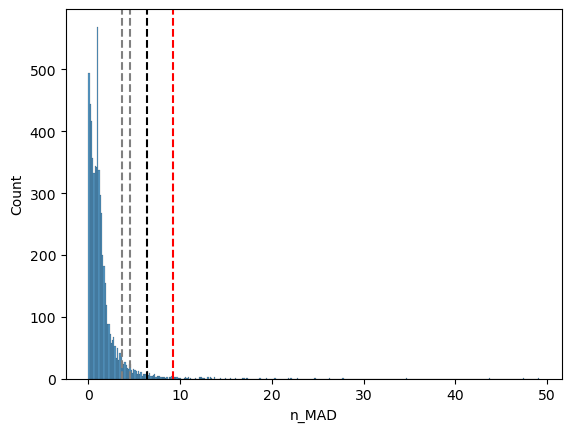

In [19]:
# Computing 95th, 97.5 and 99 percentiles
n_MAD_925_bin = np.nanpercentile(rel_MAD_bin['n_MAD'], 92.5)
n_MAD_95_bin = np.nanpercentile(rel_MAD_bin['n_MAD'], 95)
n_MAD_975_bin = np.nanpercentile(rel_MAD_bin['n_MAD'], 97.5)
n_MAD_99_bin = np.nanpercentile(rel_MAD_bin['n_MAD'], 99)

# Plotting the distribution
sns.histplot(data=rel_MAD_bin, x='n_MAD')
plt.axvline(x=n_MAD_925_bin, linestyle='--', c='grey')
plt.axvline(x=n_MAD_95_bin, linestyle='--', c='grey')
plt.axvline(x=n_MAD_975_bin, linestyle='--', c='black')
plt.axvline(x=n_MAD_99_bin, linestyle='--', c='red')

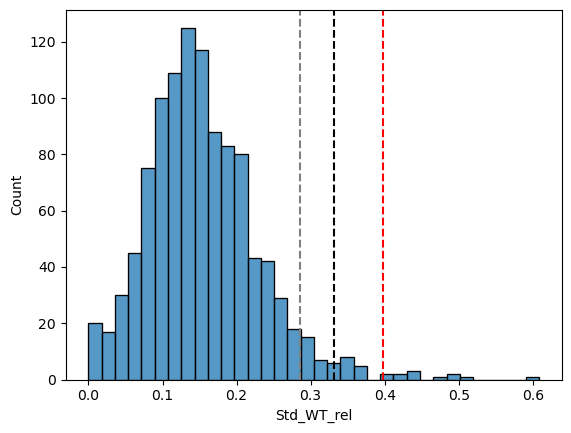

In [20]:
# Plotting the distribution of standard deviations, with 95th, 97.5th and 99th percentiles
std_95_rel = np.nanpercentile(rel_all_std['Std_WT_rel'], 95)
std_975_rel = np.nanpercentile(rel_all_std['Std_WT_rel'], 97.5)
std_99_rel = np.nanpercentile(rel_all_std['Std_WT_rel'], 99)

sns.histplot(data=rel_all_std, x='Std_WT_rel')
plt.axvline(x=std_95_rel, linestyle='--', c='grey')
plt.axvline(x=std_975_rel, linestyle='--', c='black')
plt.axvline(x=std_99_rel, linestyle='--', c='red')

Removing outlier MADs, only within genotypes with outlier standard deviation

In [22]:
# Selecting genotypes on which the filtering must be applied
out_df_rel = rel_all_std[rel_all_std['Std_WT_rel'] >= std_95_rel].copy().reset_index(drop=True)
mut_to_filter_rel = out_df_rel['Genotype'].unique()

In [23]:
# Identifying the datapoints to remove
not_filtered_rel = rel_MAD_bin[~rel_MAD_bin['Genotype'].isin(mut_to_filter_rel)].copy()
to_filter_bin = rel_MAD_bin[rel_MAD_bin['Genotype'].isin(mut_to_filter_rel)].copy()
to_filter_bin['To_remove'] = to_filter_bin['n_MAD'] > n_MAD_95_bin

# Adding back transfo replicate (mistakenly removed)
to_filter_bin['Transfo_rep'] = to_filter_bin['Lib_code'].apply(lambda x: x[0])

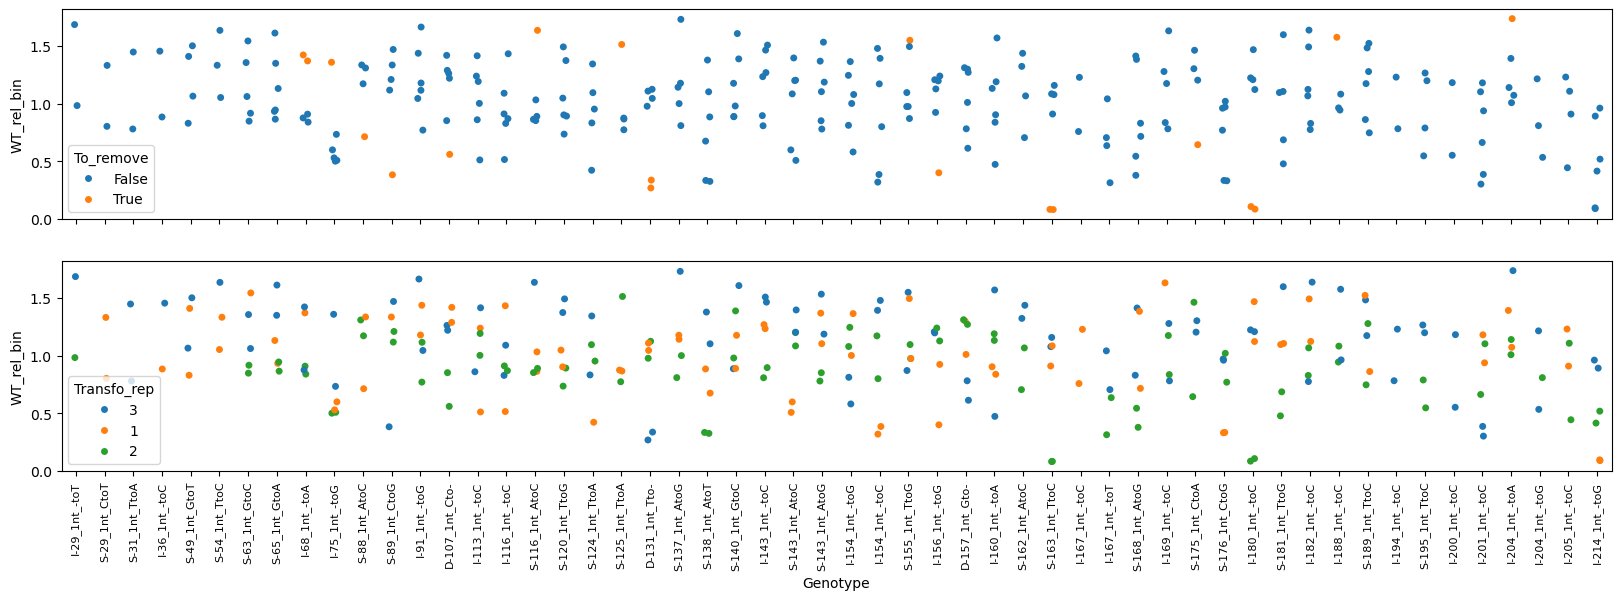

In [24]:
fig, axs = plt.subplots(2, 1, figsize=(20, 6), sharex=True)
sns.stripplot(data=to_filter_bin.sort_values(by='Position'), x='Genotype', y='WT_rel_bin', hue='To_remove', ax=axs[0])
axs[0].tick_params(axis='x', labelrotation=90)

sns.stripplot(data=to_filter_bin.sort_values(by='Position'), x='Genotype', y='WT_rel_bin', hue='Transfo_rep', ax=axs[1])
axs[1].tick_params(axis='x', labelrotation=90, labelsize=8)

#### For cell-number normalized WT-relative expression

In [26]:
rel_MAD_cell = sort_all_filtered[['Lib_code', 'Genotype', 'Mutation type', 'Position', 'In_F3F4', 'WT_rel_cell_norm']].copy()

# Adding the medians
rel_MAD_cell = pd.merge(rel_MAD_cell, rel_medians_all, on=['Genotype', 'Mutation type', 'Position', 'In_F3F4'], how='left')

# Computing the absolute deviation from the median, and then the MAD
rel_MAD_cell['Abs_med_diff_cell'] = np.abs(rel_MAD_cell['WT_rel_cell_norm'] - rel_MAD_cell['Median_WT_cell_norm'])

rel_MAD_calc = rel_MAD_cell[['Genotype', 'Position', 'In_F3F4', 'Mutation type', 'Abs_med_diff_cell']].copy()
rel_MAD_calc = rel_MAD_calc.groupby(by=['Genotype', 'Position', 'In_F3F4', 'Mutation type'], as_index=False).median()
rel_MAD_calc = rel_MAD_calc.rename(columns={'Abs_med_diff_cell': 'MAD_diff_cell'})
rel_MAD_cell = pd.merge(rel_MAD_cell, rel_MAD_calc, on=['Genotype', 'Position', 'In_F3F4', 'Mutation type'], how='left')

# For each estimate, converting each abs deviation into a number of MADs
rel_MAD_cell['n_MAD'] = rel_MAD_cell['Abs_med_diff_cell'] / rel_MAD_cell['MAD_diff_cell']

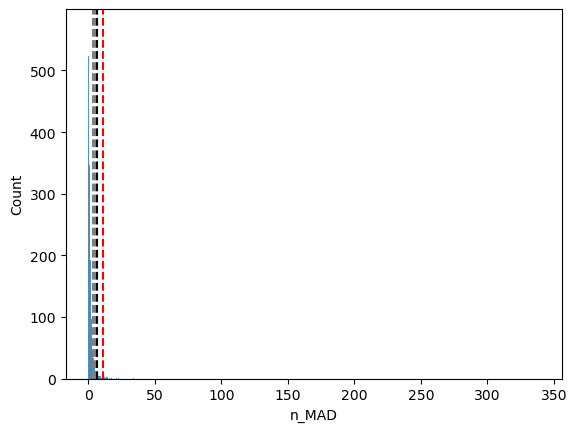

In [27]:
# Computing 95th, 97.5 and 99 percentiles
n_MAD_925_cell = np.nanpercentile(rel_MAD_cell['n_MAD'], 92.5)
n_MAD_95_cell = np.nanpercentile(rel_MAD_cell['n_MAD'], 95)
n_MAD_975_cell = np.nanpercentile(rel_MAD_cell['n_MAD'], 97.5)
n_MAD_99_cell = np.nanpercentile(rel_MAD_cell['n_MAD'], 99)

# Plotting the distribution
sns.histplot(data=rel_MAD_cell, x='n_MAD')
plt.axvline(x=n_MAD_925_cell, linestyle='--', c='grey')
plt.axvline(x=n_MAD_95_cell, linestyle='--', c='grey')
plt.axvline(x=n_MAD_975_cell, linestyle='--', c='black')
plt.axvline(x=n_MAD_99_cell, linestyle='--', c='red')

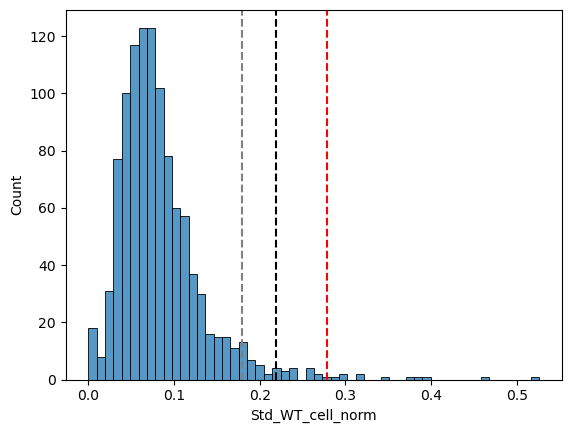

In [28]:
# Plotting the distribution of standard deviations, with 95th, 97.5th and 99th percentiles
std_95_cell = np.nanpercentile(rel_all_std['Std_WT_cell_norm'], 95)
std_975_cell = np.nanpercentile(rel_all_std['Std_WT_cell_norm'], 97.5)
std_99_cell = np.nanpercentile(rel_all_std['Std_WT_cell_norm'], 99)

sns.histplot(data=rel_all_std, x='Std_WT_cell_norm')
plt.axvline(x=std_95_cell, linestyle='--', c='grey')
plt.axvline(x=std_975_cell, linestyle='--', c='black')
plt.axvline(x=std_99_cell, linestyle='--', c='red')

Removing outlier MADs, only within genotypes with outlier standard deviation

In [30]:
# Selecting genotypes on which the filtering must be applied
out_df_cell = rel_all_std[rel_all_std['Std_WT_cell_norm'] >= std_95_rel].copy().reset_index(drop=True)
mut_to_filter_cell = out_df_cell['Genotype'].unique()

In [31]:
# Identifying the datapoints to remove
not_filtered_cell = rel_MAD_cell[~rel_MAD_cell['Genotype'].isin(mut_to_filter_cell)].copy()
to_filter_cell = rel_MAD_cell[rel_MAD_cell['Genotype'].isin(mut_to_filter_cell)].copy()
to_filter_cell['To_remove'] = to_filter_cell['n_MAD'] > n_MAD_95_cell

# Adding back transfo replicate (mistakenly removed)
to_filter_cell['Transfo_rep'] = to_filter_cell['Lib_code'].apply(lambda x: x[0])

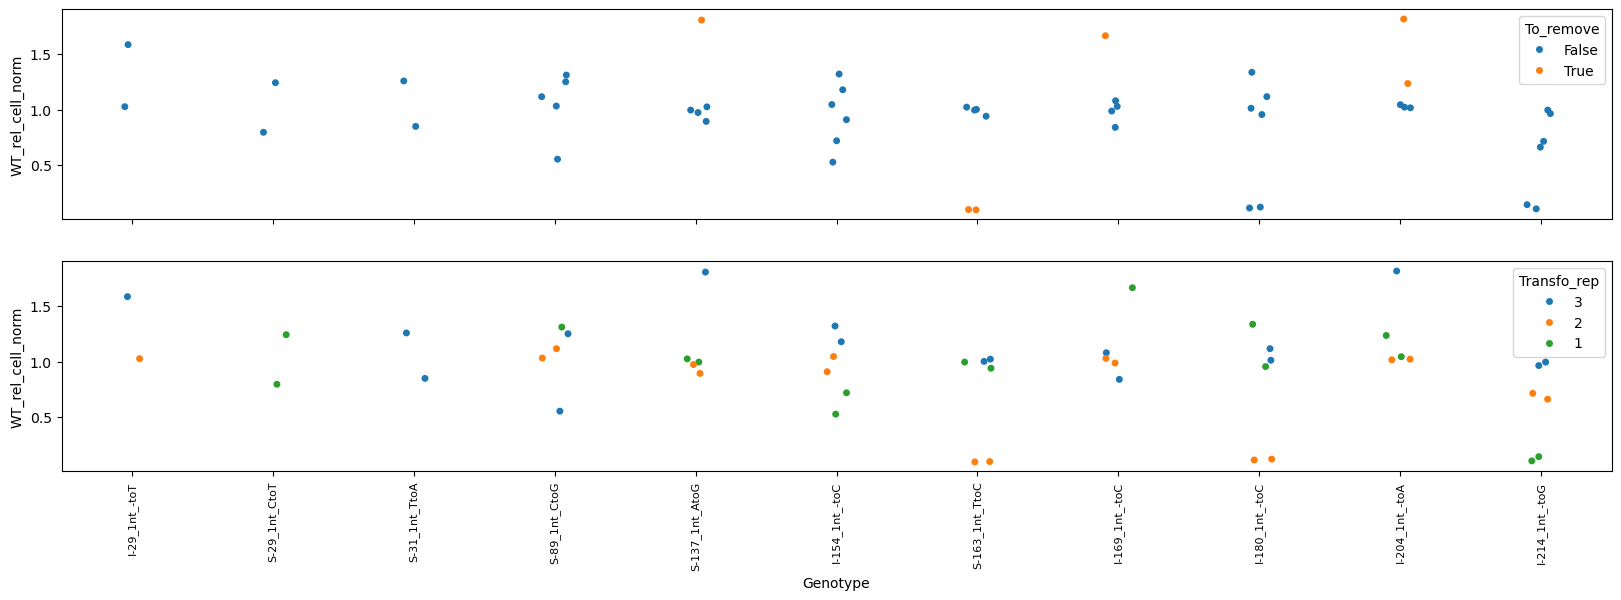

In [32]:
fig, axs = plt.subplots(2, 1, figsize=(20, 6), sharex=True)
sns.stripplot(data=to_filter_cell.sort_values(by='Position'), x='Genotype', y='WT_rel_cell_norm', hue='To_remove', ax=axs[0])
axs[0].tick_params(axis='x', labelrotation=90)

sns.stripplot(data=to_filter_cell.sort_values(by='Position'), x='Genotype', y='WT_rel_cell_norm', hue='Transfo_rep', ax=axs[1])
axs[1].tick_params(axis='x', labelrotation=90, labelsize=8)

It does not work so well here...

#### Assembling the datasets without outliers

In [35]:
# Using WT_relative expression
out_filtered_rel = to_filter_bin[to_filter_bin['To_remove'] == False].copy().reset_index(drop=True)
out_filtered_rel = out_filtered_rel.drop(columns=['To_remove', 'Transfo_rep'])
rel_no_out_bin = pd.concat([not_filtered_rel, out_filtered_rel]).reset_index(drop=True)

In [36]:
# Using cell number-normalized WT-relative expression
out_filtered_cell = to_filter_cell[to_filter_cell['To_remove'] == False].copy().reset_index(drop=True)
out_filtered_cell = out_filtered_cell.drop(columns=['To_remove', 'Transfo_rep'])
rel_no_out_cell = pd.concat([not_filtered_cell, out_filtered_cell]).reset_index(drop=True)

### Comparing these estimates with previous results and validation mutants

In [38]:
# (Re-)Computing medians
rel_bin_medians = rel_no_out_bin[['Genotype', 'Mutation type',
                                  'Position', 'In_F3F4','WT_rel_bin']].groupby(by=['Genotype', 'Mutation type','Position', 'In_F3F4'],
                                                                              as_index=False).median().reset_index(drop=True)
rel_bin_medians = rel_bin_medians.rename(columns={'WT_rel_bin': 'Median_rel_WT'})

rel_cell_medians = rel_no_out_cell[['Genotype', 'Mutation type',
                                  'Position', 'In_F3F4','WT_rel_cell_norm']].groupby(by=['Genotype', 'Mutation type', 'Position', 'In_F3F4'],
                                                                                    as_index=False).median().reset_index(drop=True)
rel_cell_medians = rel_cell_medians.rename(columns={'WT_rel_cell_norm': 'Median_rel_WT_cell'})

In [39]:
# Importing previous estimates and validation data
sort_comp = pd.read_csv('Supp_data/Sort_valid_comp.csv')
exp_predict_df = pd.read_csv('Supp_data/Rel_exp_fcy1_bootstrap.csv')

In [40]:
# Comparing the full set of scores to previous estimation (from bootstrapped calibration curve)
full_comp_bin = pd.merge(rel_bin_medians, exp_predict_df[['Genotype', 'Median_rel_exp']], on=['Genotype'], how='outer')

full_comp_cell = pd.merge(rel_cell_medians, exp_predict_df[['Genotype', 'Median_rel_exp']], on=['Genotype'], how='outer')

<Axes: xlabel='Median_rel_exp', ylabel='Median_rel_WT_cell'>

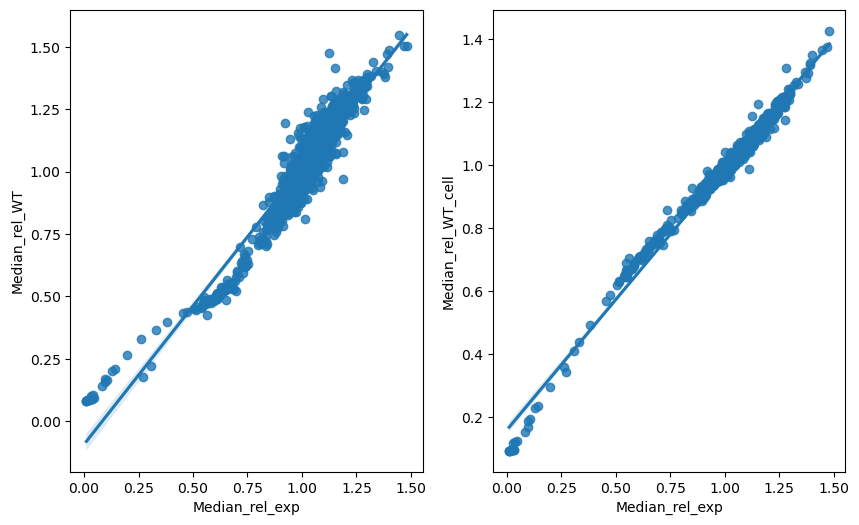

In [41]:
# Plotting the scatterplots
fig, axs = plt.subplots(1, 2, figsize=(10, 6), sharex=True)

sns.regplot(data=full_comp_bin, x='Median_rel_exp', y='Median_rel_WT', ax=axs[0])

sns.regplot(data=full_comp_cell, x='Median_rel_exp', y='Median_rel_WT_cell', ax=axs[1])

When the normalization by the number of sorted cells is performed, the correlation looks very good (and linear)

Now for the comparison with validation mutants:

In [44]:
valid_comp_bin = pd.merge(rel_bin_medians, sort_comp[['Genotype', 'Relative_median_exp', 'T_insertion', 'Median_delta_WT']],
                          on=['Genotype'], how='right')

valid_comp_cell = pd.merge(rel_cell_medians, sort_comp[['Genotype', 'Relative_median_exp', 'T_insertion', 'Median_delta_WT']], on=['Genotype'], how='right')

(0.0, 1.5)

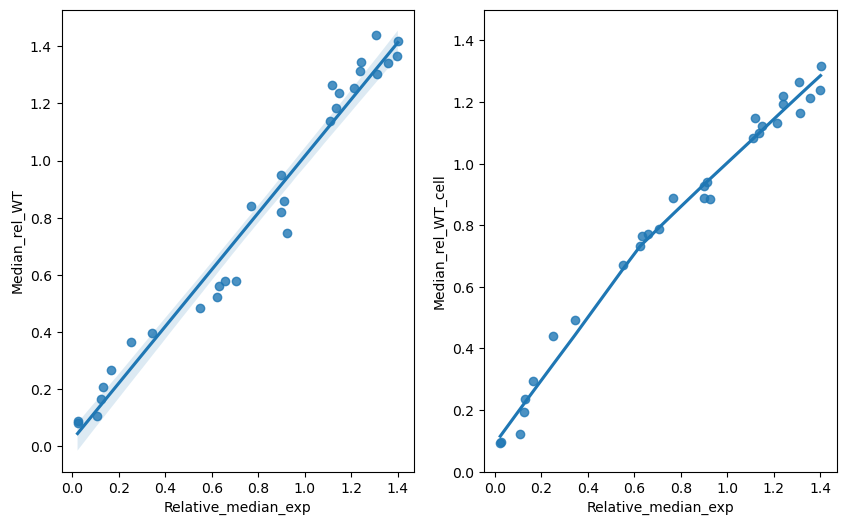

In [45]:
# Plotting the scatterplots
fig, axs = plt.subplots(1, 2, figsize=(10, 6), sharex=True)

sns.regplot(data=valid_comp_bin, x='Relative_median_exp', y='Median_rel_WT', ax=axs[0])

sns.regplot(data=valid_comp_cell, x='Relative_median_exp', y='Median_rel_WT_cell', ax=axs[1], lowess=True)
axs[1].set_ylim(0, 1.5)

In [46]:
valid_comp_cell_all = pd.merge(valid_comp_cell, exp_predict_df[['Genotype', 'Median_rel_exp']], on='Genotype', how='left')

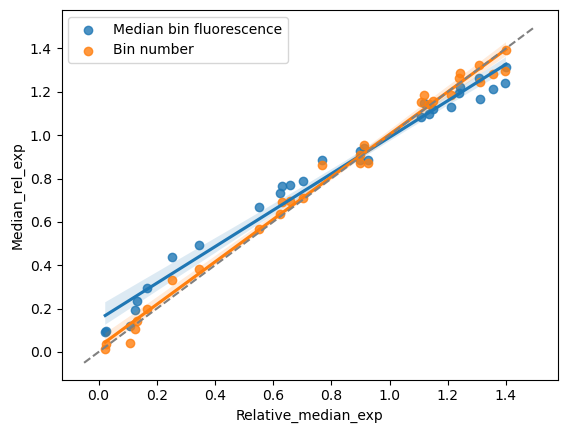

In [47]:
sns.regplot(data=valid_comp_cell_all, x='Relative_median_exp', y='Median_rel_WT_cell', label='Median bin fluorescence')
sns.regplot(data=valid_comp_cell_all, x='Relative_median_exp', y='Median_rel_exp', label='Bin number')
# Add a diagonal
diag_vals = [-0.05, 0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.5]
plt.gca().plot(diag_vals, diag_vals, linestyle='--', c='grey')
plt.gca().legend()

The correlations look good! Let's validate that the distribution of mutational effects on expression is not affected

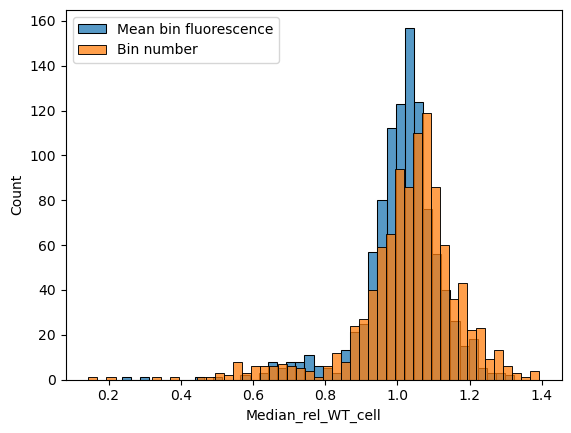

In [49]:
# Plotting the scatterplots
sns.histplot(data=full_comp_cell[full_comp_cell['In_F3F4'] == True].copy(), x='Median_rel_WT_cell', label='Mean bin fluorescence',
            binwidth=0.025)
sns.histplot(data=full_comp_cell[full_comp_cell['In_F3F4'] == True].copy(), x='Median_rel_exp', label='Bin number',
            binwidth=0.025)

plt.gca().legend()

It turns out that the distribution of effects changes significantly, but the above plot suggests that the "bin number" one is the closest to the "true" mutational effects

In [51]:
# Median effect when using mean bin fluorescence
np.median(full_comp_cell[full_comp_cell['In_F3F4'] == True]['Median_rel_WT_cell'])

1.0235385924606613

In [299]:
# Median effect when using bin number
np.median(full_comp_cell[full_comp_cell['In_F3F4'] == True]['Median_rel_exp'])

1.0523765547829824

### Generating a figure for the response to reviewers

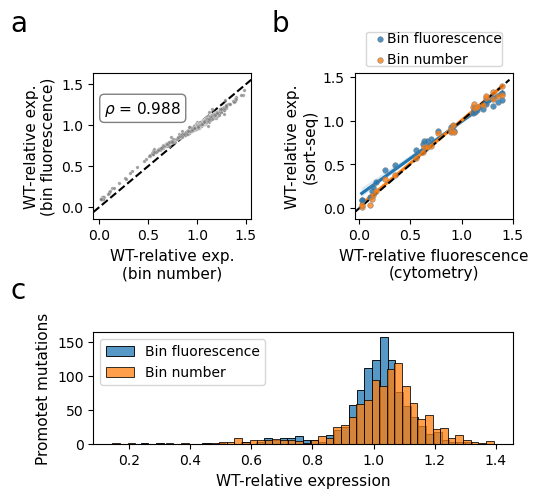

In [86]:
plt.rcParams['savefig.dpi'] = 600

# Assembling the complete figure
fig_rev = plt.figure(constrained_layout=False, figsize=(6.48, 4.5))

# First row, for A and B
gs1 = fig_rev.add_gridspec(nrows=20, ncols=20, left=0.00, right=1.00, bottom=0.5, top=1.00 )
# Second row, for C
gs2 = fig_rev.add_gridspec(nrows=20, ncols=20, left=0.00, right=1.00, bottom=0.00, top=0.5)

# Defining axes
ax1 = fig_rev.add_subplot(gs1[2:15, 4:9])
ax2 = fig_rev.add_subplot(gs1[2:15, 12:17])
ax3 = fig_rev.add_subplot(gs2[5:15, 4:17])

# Adding the plot for panel A
sns.scatterplot(data=full_comp_cell, x='Median_rel_exp', y='Median_rel_WT_cell', ax=ax1, c='grey', s=6, alpha=0.75, zorder=2)
init_xlims = ax1.get_xlim()
line_diag = np.linspace(init_xlims[0], init_xlims[1], 50)
ax1.plot(line_diag, line_diag, linestyle='--', c='black', zorder=1)
ax1.set_xlim(init_xlims)
ax1.set_xticks([0.0, 0.5, 1.0, 1.5], labels=[0.0, 0.5, 1.0, 1.5])
ax1.set_xlabel('WT-relative exp.\n(bin number)', fontsize=11)
ax1.set_ylabel('WT-relative exp.\n(bin fluorescence)', fontsize=11)
comp_calc = full_comp_cell.dropna(subset=['Median_rel_exp', 'Median_rel_WT_cell']).reset_index(drop=True)
exp_corr = stats.spearmanr(comp_calc['Median_rel_exp'], comp_calc['Median_rel_WT_cell'])
ax1.annotate(r"$\rho$ = "f'{round(exp_corr[0], 3)}',
             (0.05, 1.15), bbox=dict(boxstyle='round', fc='w', alpha=0.5), fontsize=11)

# Adding plot for panel B
sns.regplot(data=valid_comp_cell_all, x='Relative_median_exp', y='Median_rel_WT_cell',
                label='Bin fluorescence', ax=ax2, scatter_kws={'s':16, 'edgecolor':'grey', 'linewidths':0.5, 'zorder':3})
sns.regplot(data=valid_comp_cell_all, x='Relative_median_exp', y='Median_rel_exp',
                label='Bin number', ax=ax2, scatter_kws={'s':16, 'edgecolor':'grey', 'linewidths':0.5, 'zorder':3})
xlims_2 = ax2.get_xlim()
diag_vals = np.linspace(xlims_2[0], xlims_2[1], 50)
ax2.plot(diag_vals, diag_vals, linestyle='--', c='black')
ax2.set_xlim(xlims_2)
ax2.set_xticks([0.0, 0.5, 1.0, 1.5], labels=[0.0, 0.5, 1.0, 1.5])
h_2, l_2 = ax2.get_legend_handles_labels()
ax2.legend(h_2, l_2, handletextpad=-0.5, title=None, loc="upper center",
           borderaxespad=0.15, borderpad=00, fontsize=10, bbox_to_anchor=(0.5, 1.3))
ax2.set_xlabel('WT-relative fluorescence\n(cytometry)', fontsize=11)
ax2.set_ylabel('WT-relative exp.\n(sort-seq)', fontsize=11)

# Adding plot for panel C
sns.histplot(data=full_comp_cell[full_comp_cell['In_F3F4'] == True].copy(), x='Median_rel_WT_cell', label='Bin fluorescence', ax=ax3,
            binwidth=0.025)
sns.histplot(data=full_comp_cell[full_comp_cell['In_F3F4'] == True].copy(), x='Median_rel_exp', label='Bin number', ax=ax3,
            binwidth=0.025)
ax3.set_xlabel('WT-relative expression', fontsize=11)
ax3.set_ylabel('Promotet mutations', fontsize=11)
ax3.legend(fontsize=10)

# Adding identifiers for each panel
ax1.annotate('a', (-60, 135), xycoords='axes points', annotation_clip=False, fontsize=20)
ax2.annotate('b', (-60, 135), xycoords='axes points', annotation_clip=False, fontsize=20)
ax3.annotate('c', (-60, 105), xycoords='axes points', annotation_clip=False, fontsize=20)

fig = plt.gcf()
fig.savefig(f"Supp_figs/Sort_fluo.png", bbox_inches='tight')